In [1]:
# import pyvisa
import numpy as np
import time
import pickle
from datetime import datetime

In [ ]:
# rm = pyvisa.ResourceManager()
# # pump = rm.open_resource("TCPIP0::192.168.111.122::inst0::INSTR")
# pump = rm.open_resource("TCPIP0::192.168.111.169::inst0::INSTR")

# """Sets power in dBm"""
# pump.write(f":POW {2}")
# # Synchronize (wait until all previous commands have been executed completely)
# pump.query("*OPC?")

'1\n'

In [ ]:
# pump_on=False
# if pump_on:
#     pump.write(f"OUTP ON")
# else:
#     pump.write(f"OUTP OFF")
# # Synchronize (wait until all previous commands have been executed completely)
# pump.query("*OPC?")

'1\n'

In [ ]:
# np.average([np.aray([1,2]),np.array([3,4])],axis=1)

array([1.5, 3.5])

[ 0.121  0.116  0.111  0.106  0.101  0.096  0.091  0.086  0.081  0.076
  0.071  0.066  0.061  0.056  0.051  0.046  0.041  0.036  0.031  0.026
  0.021  0.016  0.011  0.006  0.001 -0.004 -0.009 -0.014 -0.019 -0.024
 -0.029 -0.034 -0.039 -0.044 -0.049 -0.054 -0.059 -0.064 -0.069 -0.074
 -0.079 -0.084 -0.089 -0.094 -0.099 -0.104 -0.109]


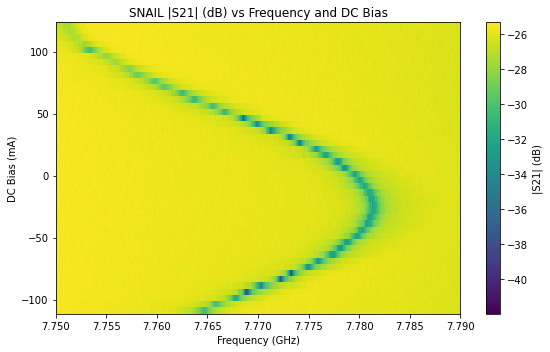

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing pickle files
folder = Path(r"C:\Users\qcrew\Documents\eunice\data\2026-02-04")

# DC bias values (A)
dc_bias_list = np.arange(start=121000, stop=-111000, step=-5000) * 1e-6  # in amps A

plot_data = []
freq_list = []

for dc_bias in dc_bias_list:
    file = folder / f"snaillm_s21_sweep_freq_dc_bias_{dc_bias}.pkl"

    with open(file, "rb") as f:
        data = pickle.load(f)

    freq = np.asarray(data["freq"])
    real = np.asarray(data["real"])
    imag = np.asarray(data["imag"])

    # Complex S21 and average over repetitions
    s21 = real + 1j * imag
    s21_avg = np.mean(s21, axis=0)

    mag = np.abs(s21_avg)
    plot_data.append(mag)
    freq_list.append(freq)

# Convert to 2D array: shape (len(dc_bias), len(freq))
plot_data = np.array(plot_data)
freq_list = np.array(freq_list)

# Convert magnitude to dB
plot_data_db = 10 * np.log10(plot_data)

# ---- Plotting ----
fig, ax = plt.subplots(figsize=(8, 5))

print(dc_bias_list)

pcm = ax.pcolor(
    freq_list / 1e9,
    dc_bias_list * 1e3,   # convert to µA for readability
    plot_data_db,
    shading="auto",
    cmap="viridis"
)

# Axes formatting
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("DC Bias (mA)")
ax.set_title("SNAIL |S21| (dB) vs Frequency and DC Bias")

# Colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("|S21| (dB)")

plt.tight_layout()
plt.show()


In [6]:
plot_data_db

array([[-26.58866995, -26.72162622, -26.51476363, ..., -26.37429499,
        -26.234043  , -26.25228701],
       [-26.38955726, -26.40622625, -26.45189839, ..., -26.34707247,
        -26.24118154, -26.29703088],
       [-26.12856931, -26.13485439, -26.13293857, ..., -26.32828459,
        -26.20759762, -26.3249832 ],
       ...,
       [-25.61438591, -25.53891345, -25.57117321, ..., -26.29950087,
        -26.2261369 , -26.25231199],
       [-25.6596333 , -25.52236818, -25.54986707, ..., -26.14373649,
        -26.30150994, -26.07539788],
       [-25.60811583, -25.592512  , -25.48969239, ..., -26.22513693,
        -26.24146171, -26.20523222]])

In [3]:
# example data
freq_GHz = freq_list / 1e9
current_uA = dc_bias_list * 1e3,   # convert to µA for readability
amp_dB = plot_data_db


np.savez(
    "20260204_snaillm_onetone_fluxsweep.npz",
    freq_GHz=freq_GHz,
    current_uA=current_uA,
    y_amp_dBfit=amp_dB
)

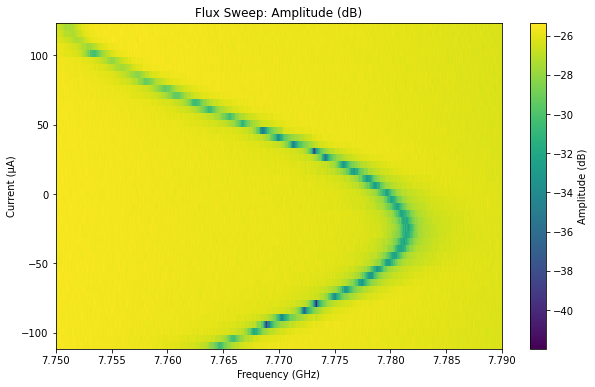

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load the npz file
data = np.load("20260204_snaillm_onetone_fluxsweep.npz")

freq = data["freq_GHz"]            # shape: (47, 5001)
current = data["current_uA"].flatten()  # shape: (47,)
amp_dB = data["y_amp_dBfit"]       # shape: (47, 5001)

# Make heatmap
plt.figure(figsize=(10,6))
plt.pcolormesh(freq[0], current, amp_dB, shading='auto', cmap='viridis')  
# Note: freq[0] since freq is 2D (47,5001) – take first row
plt.xlabel("Frequency (GHz)")
plt.ylabel("Current (µA)")
plt.title("Flux Sweep: Amplitude (dB)")
plt.colorbar(label="Amplitude (dB)")
plt.show()


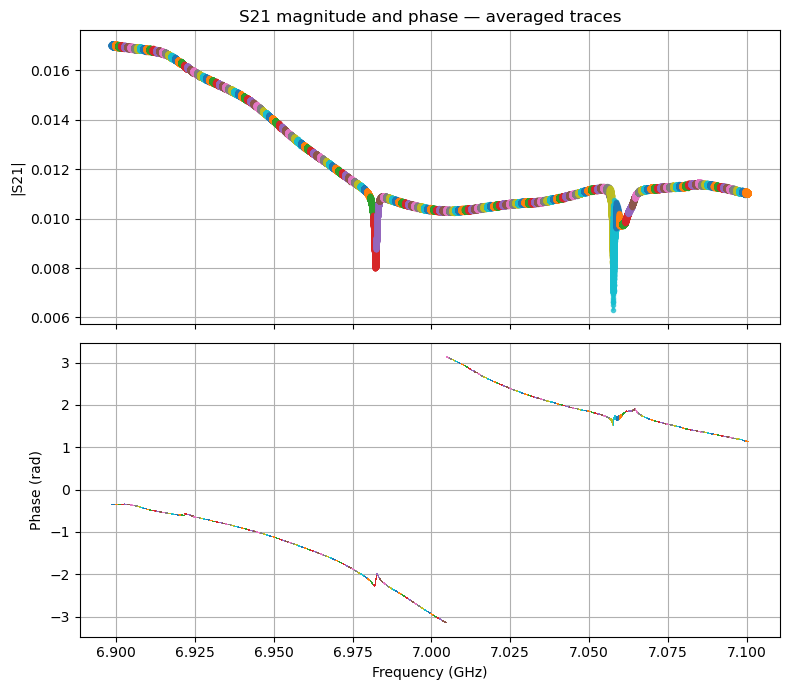

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing pickle files
folder = Path(r"C:\Users\qcrew5\Documents\Candace\hp_l_vna_sweep\20251229_100hz")

# Find all matching pickle files
files = sorted(folder.glob("s21_sweep_power_-20*.pkl"))

fig, (ax_mag, ax_phase) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True
)

for file in files:
    with open(file, "rb") as f:
        data = pickle.load(f)

    freq = np.array(data["freq"])
    real = np.array(data["real_list"])
    imag = np.array(data["imag_list"])

    s21 = real + 1j * imag
    s21_avg = np.mean(s21, axis=0)

    mag = np.abs(s21_avg)
    phase = np.unwrap(np.angle(s21_avg))

    ax_mag.plot(freq / 1e9, mag,".-", alpha=0.7)
    ax_phase.plot(freq / 1e9, phase,",", alpha=0.7)

# Formatting
ax_mag.set_ylabel("|S21|")
# ax_mag.set_yscale("10*log")
ax_mag.set_title("S21 magnitude and phase — averaged traces")
ax_mag.grid(True)


ax_phase.set_ylabel("Phase (rad)")
ax_phase.set_xlabel("Frequency (GHz)")
ax_phase.grid(True)

# ax_phase.set_xlim(6.91 ,6.925)
# ax_phase.set_xlim(6.3 ,6.4)
# ax_phase.set_xlim(5.999,6.001)

# ax_mag.set_ylim(0.06, 0.08)
# ax_mag.set_ylim(0.014, 0.016)
# ax_phase.set_ylim(-3, -1)


plt.tight_layout()
plt.show()


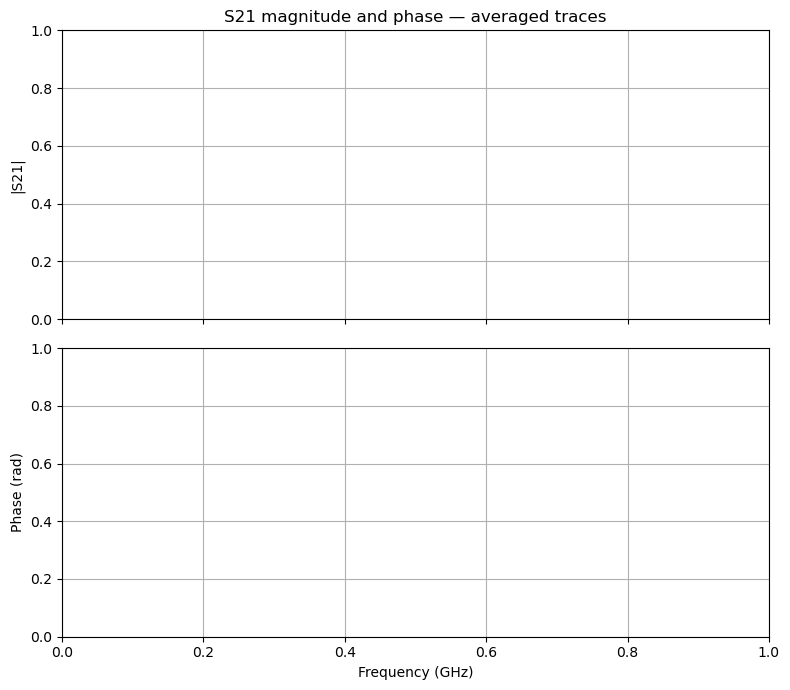

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing pickle files
folder = Path(r"C:\Users\qcrew5\Documents\Candace\hp_l_vna_sweep")

# Find all matching pickle files
files = sorted(folder.glob("s21_sweep_power_-20*.pkl"))

fig, (ax_mag, ax_phase) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True
)

for file in files:
    with open(file, "rb") as f:
        data = pickle.load(f)

    freq = np.array(data["freq"])
    real = np.array(data["real_list"])
    imag = np.array(data["imag_list"])

    s21 = real + 1j * imag
    s21_avg = np.mean(s21, axis=0)

    mag = np.abs(s21_avg)
    phase = np.unwrap(np.angle(s21_avg))

    ax_mag.plot(freq / 1e9, mag,".-", alpha=0.7)
    ax_phase.plot(freq / 1e9, phase,",", alpha=0.7)

# Formatting
ax_mag.set_ylabel("|S21|")
# ax_mag.set_yscale("10*log")
ax_mag.set_title("S21 magnitude and phase — averaged traces")
ax_mag.grid(True)


ax_phase.set_ylabel("Phase (rad)")
ax_phase.set_xlabel("Frequency (GHz)")
ax_phase.grid(True)

# ax_phase.set_xlim(6.91 ,6.925)
# ax_phase.set_xlim(6.3 ,6.4)
# ax_phase.set_xlim(5.999,6.001)

# ax_mag.set_ylim(0.06, 0.08)
# ax_mag.set_ylim(0.014, 0.016)
# ax_phase.set_ylim(-3, -1)


plt.tight_layout()
plt.show()


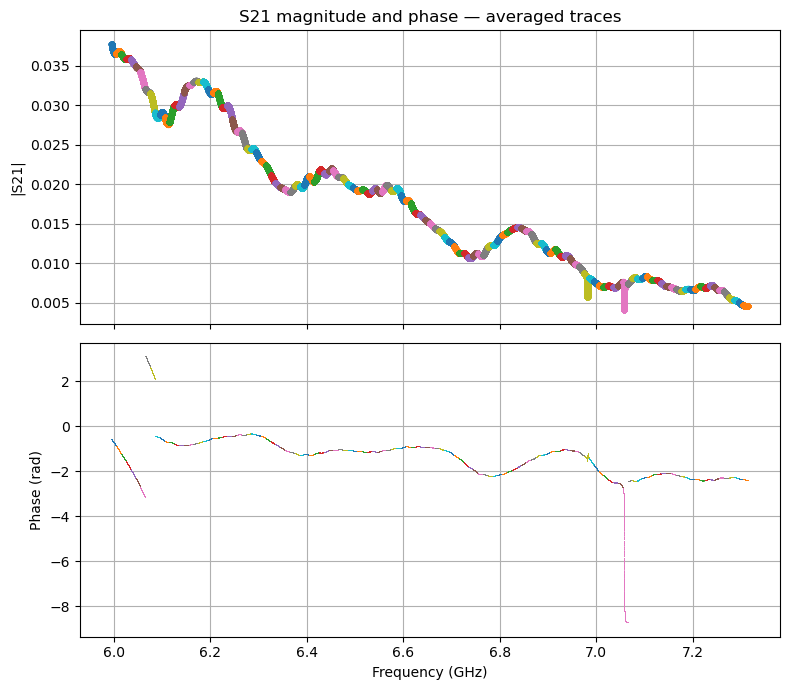

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing pickle files
folder = Path(r"C:\Users\qcrew5\Documents\Candace\hp_l_vna_sweep")

# Find all matching pickle files
files = sorted(folder.glob("s21_sweep_power_0*.pkl"))

fig, (ax_mag, ax_phase) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True
)

for file in files:
    with open(file, "rb") as f:
        data = pickle.load(f)

    freq = np.array(data["freq"])
    real = np.array(data["real_list"])
    imag = np.array(data["imag_list"])

    s21 = real + 1j * imag
    s21_avg = np.mean(s21, axis=0)

    mag = np.abs(s21_avg)
    phase = np.unwrap(np.angle(s21_avg))

    ax_mag.plot(freq / 1e9, mag,".-", alpha=0.7)
    ax_phase.plot(freq / 1e9, phase,",", alpha=0.7)

# Formatting
ax_mag.set_ylabel("|S21|")
# ax_mag.set_yscale("log")
ax_mag.set_title("S21 magnitude and phase — averaged traces")
ax_mag.grid(True)


ax_phase.set_ylabel("Phase (rad)")
ax_phase.set_xlabel("Frequency (GHz)")
ax_phase.grid(True)

# ax_phase.set_xlim(6.369 ,6.371)
# ax_phase.set_xlim(6.3 ,6.4)
# ax_phase.set_xlim(5.999,6.001)

# ax_mag.set_ylim(0.06, 0.08)
# ax_mag.set_ylim(0.014, 0.016)
# ax_phase.set_ylim(-3, -1)


plt.tight_layout()
plt.show()


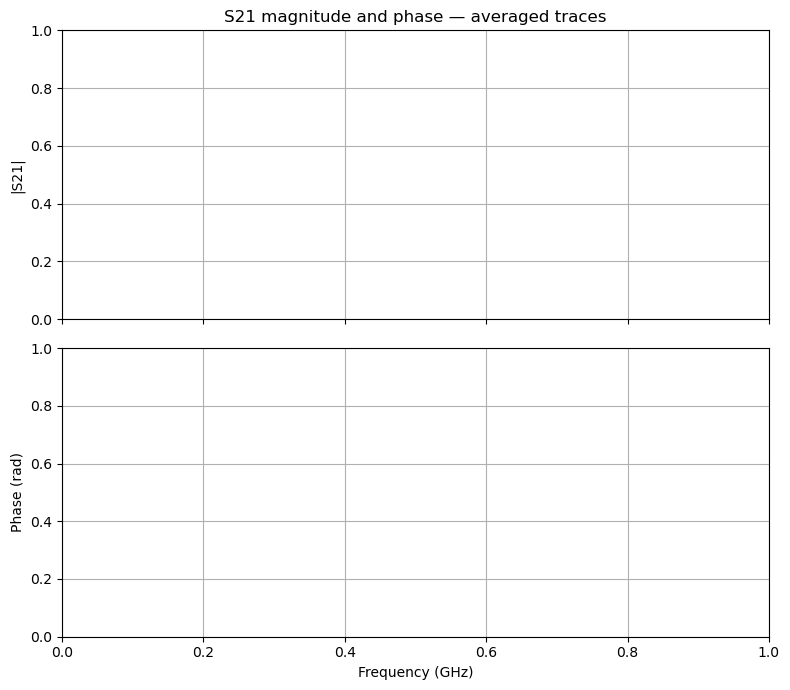

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing pickle files
folder = Path(r"C:\Users\qcrew5\Documents\Candace\hp_l_vna_sweep")

# Find all matching pickle files
files = sorted(folder.glob("s21_sweep_power_-40*.pkl"))

fig, (ax_mag, ax_phase) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True
)

for file in files:
    with open(file, "rb") as f:
        data = pickle.load(f)

    freq = np.array(data["freq"])
    real = np.array(data["real_list"])
    imag = np.array(data["imag_list"])

    s21 = real + 1j * imag
    s21_avg = np.mean(s21, axis=0)

    mag = np.abs(s21_avg)
    phase = np.unwrap(np.angle(s21_avg))

    ax_mag.plot(freq / 1e9, mag,".-", alpha=0.7)
    ax_phase.plot(freq / 1e9, phase,",", alpha=0.7)

# Formatting
ax_mag.set_ylabel("|S21|")
# ax_mag.set_yscale("log")
ax_mag.set_title("S21 magnitude and phase — averaged traces")
ax_mag.grid(True)


ax_phase.set_ylabel("Phase (rad)")
ax_phase.set_xlabel("Frequency (GHz)")
ax_phase.grid(True)

# ax_phase.set_xlim(6.369 ,6.371)
# ax_phase.set_xlim(6.3 ,6.4)
# ax_phase.set_xlim(5.999,6.001)

# ax_mag.set_ylim(0.06, 0.08)
# ax_mag.set_ylim(0.014, 0.016)
# ax_phase.set_ylim(-3, -1)


plt.tight_layout()
plt.show()
